In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Saran\Downloads\archive (2)\digital_wallet_ltv_dataset.csv")



In [9]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  7000 non-null   object 
 1   Age                          7000 non-null   int64  
 2   Location                     7000 non-null   object 
 3   Income_Level                 7000 non-null   object 
 4   Total_Transactions           7000 non-null   int64  
 5   Avg_Transaction_Value        7000 non-null   float64
 6   Max_Transaction_Value        7000 non-null   float64
 7   Min_Transaction_Value        7000 non-null   float64
 8   Total_Spent                  7000 non-null   float64
 9   Active_Days                  7000 non-null   int64  
 10  Last_Transaction_Days_Ago    7000 non-null   int64  
 11  Loyalty_Points_Earned        7000 non-null   int64  
 12  Referral_Count               7000 non-null   int64  
 13  Cashback_Received 

Customer_ID                    0
Age                            0
Location                       0
Income_Level                   0
Total_Transactions             0
Avg_Transaction_Value          0
Max_Transaction_Value          0
Min_Transaction_Value          0
Total_Spent                    0
Active_Days                    0
Last_Transaction_Days_Ago      0
Loyalty_Points_Earned          0
Referral_Count                 0
Cashback_Received              0
App_Usage_Frequency            0
Preferred_Payment_Method       0
Support_Tickets_Raised         0
Issue_Resolution_Time          0
Customer_Satisfaction_Score    0
LTV                            0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)
df.columns = df.columns.str.lower()

In [16]:
#Customer Value Score
df['customer_value_score'] = (
    (df['ltv'] * 0.4) +
    (df['total_spent'] * 0.3) +
    (df['total_transactions'] * 0.2) +
    (df['loyalty_points_earned'] * 0.1)
)

print(df[['customer_id', 'customer_value_score']].head())



  customer_id  customer_value_score
0   cust_0000          1.095447e+06
1   cust_0001          4.844752e+06
2   cust_0002          7.941158e+05
3   cust_0003          4.017662e+05
4   cust_0004          3.227900e+06


In [18]:
#Engagement Score
df['engagement_score'] = (
    (df['active_days'] * 0.5) +
    (df['referral_count'] * 0.3) +
    (df['total_transactions'] * 0.2)
)

print(df[['customer_id', 'engagement_score']].head())

  customer_id  engagement_score
0   cust_0000             115.9
1   cust_0001             316.3
2   cust_0002             102.3
3   cust_0003             174.2
4   cust_0004             299.0


In [19]:
#High-Value Customer Segmentation
def segment(score):
    if score >= df['customer_value_score'].quantile(0.80):
        return 'Premium'
    elif score >= df['customer_value_score'].quantile(0.60):
        return 'Gold'
    elif score >= df['customer_value_score'].quantile(0.40):
        return 'Silver'
    else:
        return 'Basic'

df['customer_segment'] = df['customer_value_score'].apply(segment)

print(df[['customer_id', 'customer_value_score', 'customer_segment']].head())

  customer_id  customer_value_score customer_segment
0   cust_0000          1.095447e+06           Silver
1   cust_0001          4.844752e+06          Premium
2   cust_0002          7.941158e+05            Basic
3   cust_0003          4.017662e+05            Basic
4   cust_0004          3.227900e+06          Premium


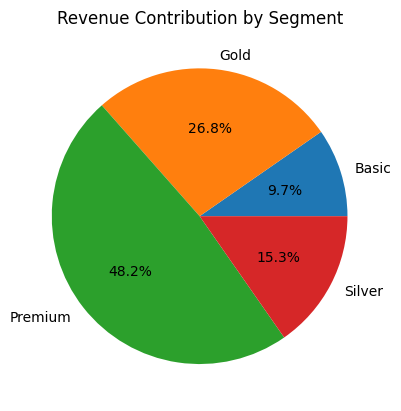

In [20]:
#Customer Segment Revenue Contribution
import matplotlib.pyplot as plt

segment_revenue = df.groupby(
    'customer_segment'
)['ltv'].sum()

segment_revenue.plot(kind='pie', autopct='%1.1f%%')

plt.title("Revenue Contribution by Segment")
plt.ylabel("")
plt.show()

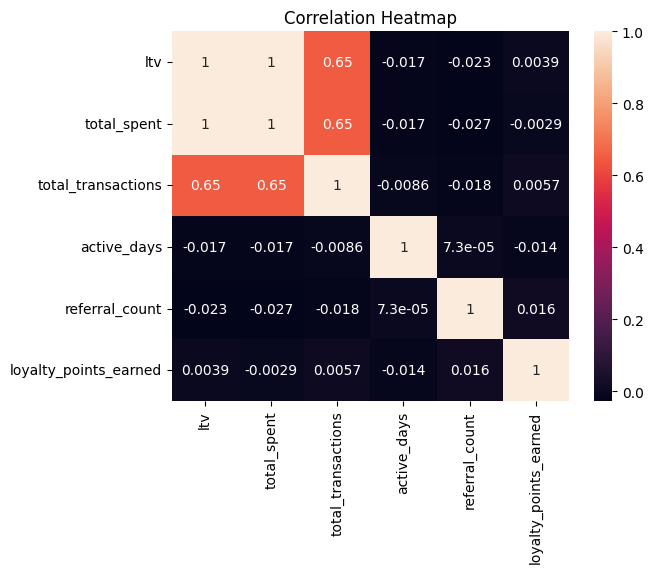

In [21]:
#What Drives High LTV
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[[
    'ltv',
    'total_spent',
    'total_transactions',
    'active_days',
    'referral_count',
    'loyalty_points_earned'
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

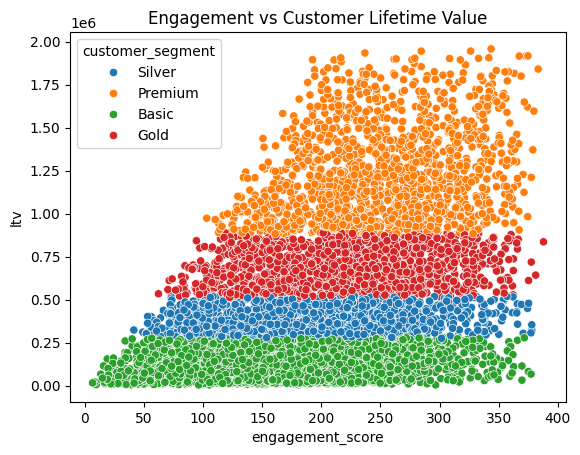

In [22]:
#Engagement vs LTV
sns.scatterplot(
    x='engagement_score',
    y='ltv',
    hue='customer_segment',
    data=df
)

plt.title("Engagement vs Customer Lifetime Value")
plt.show()

In [23]:
#High-Value Customer Behavior Analysis
premium = df[
    df['customer_segment'] == 'Premium'
]

print(premium.describe())

#Understand:

#Spending patterns
#Usage behavior
#Transaction habits

#This helps businesses replicate profitable customer behavior.

               age  total_transactions  avg_transaction_value  \
count  1400.000000         1400.000000            1400.000000   
mean     42.461429          781.325714           15829.116286   
std      15.295187          142.117086            2741.446945   
min      16.000000          444.000000            8774.956940   
25%      29.000000          670.000000           13844.345472   
50%      43.000000          798.000000           16092.705583   
75%      56.000000          903.000000           18184.316090   
max      69.000000         1000.000000           19995.491807   

       max_transaction_value  min_transaction_value   total_spent  \
count            1400.000000            1400.000000  1.400000e+03   
mean            48245.290235            4790.160315  1.221690e+07   
std             20451.483902            2062.569233  2.621443e+06   
min              9378.009576             979.865514  8.704490e+06   
25%             31199.681112            3039.770058  1.002905e+07   


In [24]:
#Acquisition Cost Efficiency
import numpy as np

# Simulated acquisition cost
df['acquisition_cost'] = np.random.randint(100, 1000, size=len(df))

# LTV to CAC ratio
df['ltv_to_cac_ratio'] = (
    df['ltv'] /
    (df['acquisition_cost'] + 1)
)

print(df[['customer_id', 'ltv', 'acquisition_cost', 'ltv_to_cac_ratio']].head())

#This is a REAL industry KPI.

#High ratio:
#✔ profitable customers
#✔ smart investment

  customer_id           ltv  acquisition_cost  ltv_to_cac_ratio
0   cust_0000  3.279546e+05               149       2186.363781
1   cust_0001  1.437053e+06               727       1973.973783
2   cust_0002  2.419387e+05               474        509.344546
3   cust_0003  1.284599e+05               810        158.396911
4   cust_0004  9.569514e+05               115       8249.580807


In [25]:
#Identify Customers Worth Investing In
investment_targets = df[
    (df['customer_segment'] == 'Premium') &
    (df['engagement_score'] > df['engagement_score'].mean())
]

print(
    investment_targets.head()
)

   customer_id  age  location income_level  total_transactions  \
1    cust_0001   67  Suburban         High                 979   
4    cust_0004   58     Urban       Middle                 878   
12   cust_0012   39     Rural         High                 772   
17   cust_0017   18     Urban       Middle                 594   
20   cust_0020   17     Urban         High                 911   

    avg_transaction_value  max_transaction_value  min_transaction_value  \
1            14536.734683           48350.100272            2186.742245   
4            10800.092660           17497.634534            4532.872520   
12           13358.322191           19570.911891            4999.855537   
17           19123.752021           87283.024002            6116.877761   
20           10641.109019           16130.510000            2920.559916   

     total_spent  active_days  ...  preferred_payment_method  \
1   1.423146e+07          229  ...                       UPI   
4   9.482481e+06        